In [2]:
!nvidia-smi || echo "No GPU detected — switch Runtime to T4 GPU"

Thu May 28 11:30:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
REPO_URL = "https://github.com/Diyakalra1/skillgraph-adaptive-llm.git"
BRANCH = "main"
REPO_DIR = "/content/repo"  # Colab working copy (run setup cell before training cells)

In [4]:
import os
import subprocess
import sys

!rm -rf {REPO_DIR}
!git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
os.chdir(REPO_DIR)
print("cwd:", os.getcwd())

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-r", "skillgraph_adaptive_env/training/requirements-colab.txt"]
)

pip_code = subprocess.call(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "skillgraph_adaptive_env"]
)
if pip_code != 0:
    print("pip -e failed; using PYTHONPATH (this is OK on Colab)")
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
else:
    print("pip -e OK")

import importlib

mod = importlib.import_module("skillgraph_adaptive_env.training.run_training_three_models")
print("import OK:", mod.__file__)


Cloning into '/content/repo'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (259/259), done.
remote: Total 381 (delta 197), reused 283 (delta 107), pack-reused 0 (from 0)
Receiving objects: 100% (381/381), 2.09 MiB | 7.99 MiB/s, done.
Resolving deltas: 100% (197/197), done.
cwd: /content/repo
pip -e OK


ModuleNotFoundError: No module named 'skillgraph_adaptive_env.training.run_training_three_models'

In [ ]:
%cd /content/repo
!git pull

In [7]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN").strip()

In [17]:
%cd /content/repo
from pathlib import Path

p = Path("skillgraph_adaptive_env/training/run_training_trl_grpo.py")
s = p.read_text()

s = s.replace("per_device_train_batch_size=1", "per_device_train_batch_size=2")
s = s.replace("num_generations=2", "num_generations=2")  # keep 2
p.write_text(s)
print("Patched batch_size=2, num_generations=2")

/content
Patched batch_size=2, num_generations=2


In [28]:
!python -m skillgraph_adaptive_env.training.run_training_trl_grpo \
  --episodes 10 \
  --seed 7 \
  --max-turns 6 \
  --model-id Qwen/Qwen2.5-0.5B-Instruct \
  --rollout-model-id meta-llama/Llama-3.2-1B-Instruct \
  --hf-token "$HF_TOKEN" \
  --rollout-max-tokens 64 \
  --rollout-temperature 0.8 \
  --max-samples 70 \
  --epochs 1 \
  --max-completion-length 28 \
  --batch-size 2 \
  --grad-accum-steps 2 \
  --num-generations 2 \
  --grpo-temperature 0.9 \
  --out-dir training/runs/trl_grpo_tuned_10ep

[EP 01 | TURN 01] agent_gamma | task=collaborative | difficulty=3.00
Q: You are agent_gamma in a multi-agent adaptive curriculum task.
Task type: collaborative
Task: Synthesize findings from 3 reports about public transport safety and propose one shared recommendation for Kochi.
Skills: information_synthesis, collaboration, communication_clarity
Turn: 0/12
Give one concise actionable response.
A: I'd like to propose a shared recommendation for Kochi's public transport safety. After reviewing reports on bus stops and intersections, it appears that congestion is a significant issue, particularly during peak hours. A proposed solution could be implementing real-time traffic monitoring and smart traffic signals to optimize routing and reduce congestion.

[EP 01 | TURN 02] agent_alpha | task=collaborative | difficulty=3.00
Q: You are agent_alpha in a multi-agent adaptive curriculum task.
Task type: collaborative
Task: Synthesize findings from 3 reports about public transport safety and prop

In [32]:
!python -m skillgraph_adaptive_env.training.run_training_trl_grpo \
  --train-only \
  --model-id Qwen/Qwen2.5-0.5B-Instruct \
  --max-samples 70 \
  --epochs 5 \
  --max-completion-length 28 \
  --batch-size 2 \
  --grad-accum-steps 2 \
  --num-generations 2 \
  --grpo-temperature 0.9 \
  --out-dir training/runs/trl_grpo_tuned_10ep

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
  0% 0/130 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
{'loss': -0.0, 'grad_norm': 17.97360610961914, 'learning_rate': 1.953846153846154e-05, 'rewards/reward_fn': 0.4161999985575676, 'reward': 0.4161999985575676, 'reward_std': 0.011313706636428833, 'completion_length': 28.0, 'kl': 0.0, 'epoch': 0.19}
{'loss': 0.0178, 'grad_norm': 0.9988998770713806, 'learning_rate': 1.876923076923077e-05, 'rewards/reward_fn': 0.42312000393867494, 'reward': 0.42312000393867494, 'reward_std': 0.005656854063272476, 'completion_length': 28.0, 'kl': 0.44422085732221606, 'epoch': 0.38}
{'loss': 0.0231, 'grad_norm': 18.242952346801758, 'learning_rate': 1.8153846153

In [33]:
final upar vala

SyntaxError: invalid syntax (104759448.py, line 1)

In [30]:
from transformers import AutoModelForCausalLM

m = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", torch_dtype="auto", device_map="auto")
total = sum(p.numel() for p in m.parameters())
trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
print("trainable/total:", trainable, "/", total, "=>", trainable/total)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


trainable/total: 494032768 / 494032768 => 1.0


In [31]:
%cd /content/repo
!git pull

/content
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.06 KiB | 109.00 KiB/s, done.
From https://github.com/Diyakalra1/skillgraph-adaptive-llm
   c30adc1..b0d5415  main       -> origin/main
Updating c30adc1..b0d5415
Fast-forward
 .../training/run_training_trl_grpo.py              | 36 +++++++++++++++++++---
 1 file changed, 31 insertions(+), 5 deletions(-)



reward_vs_steps.png


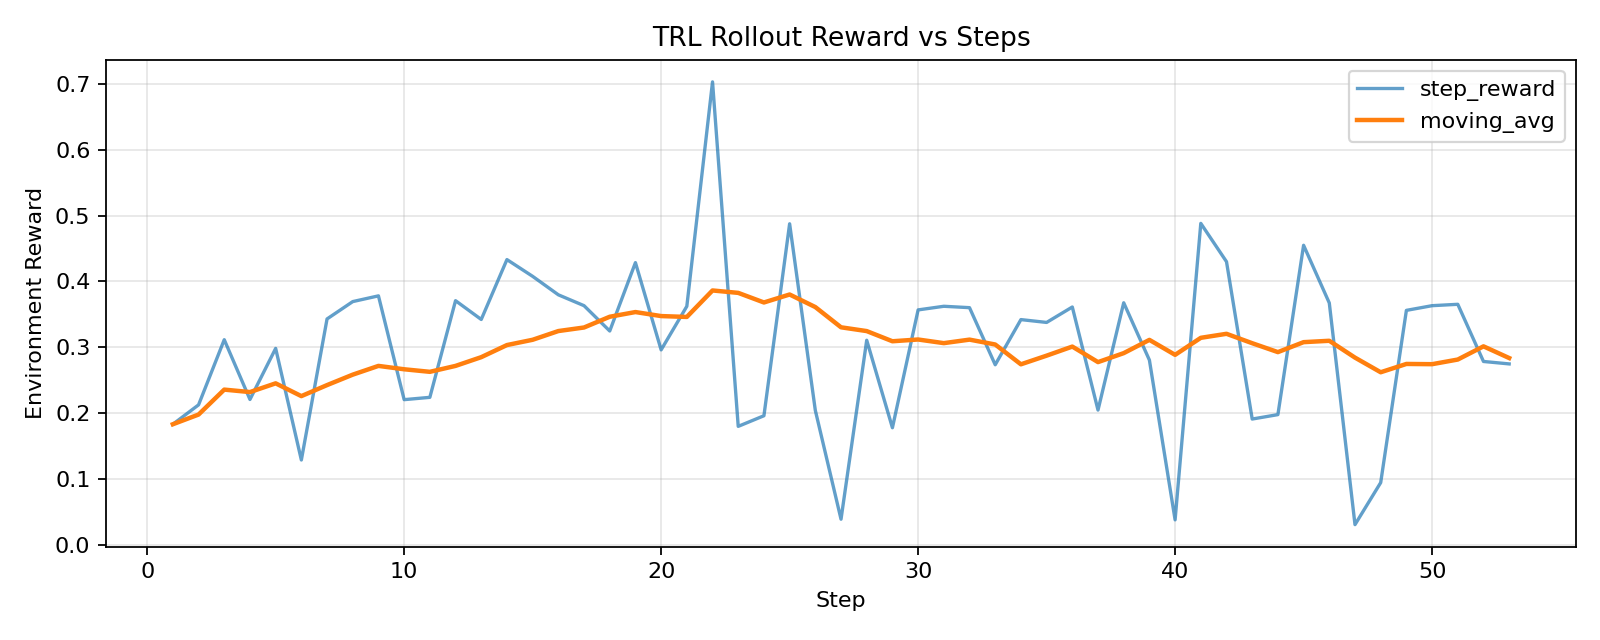


success_rate_trend.png


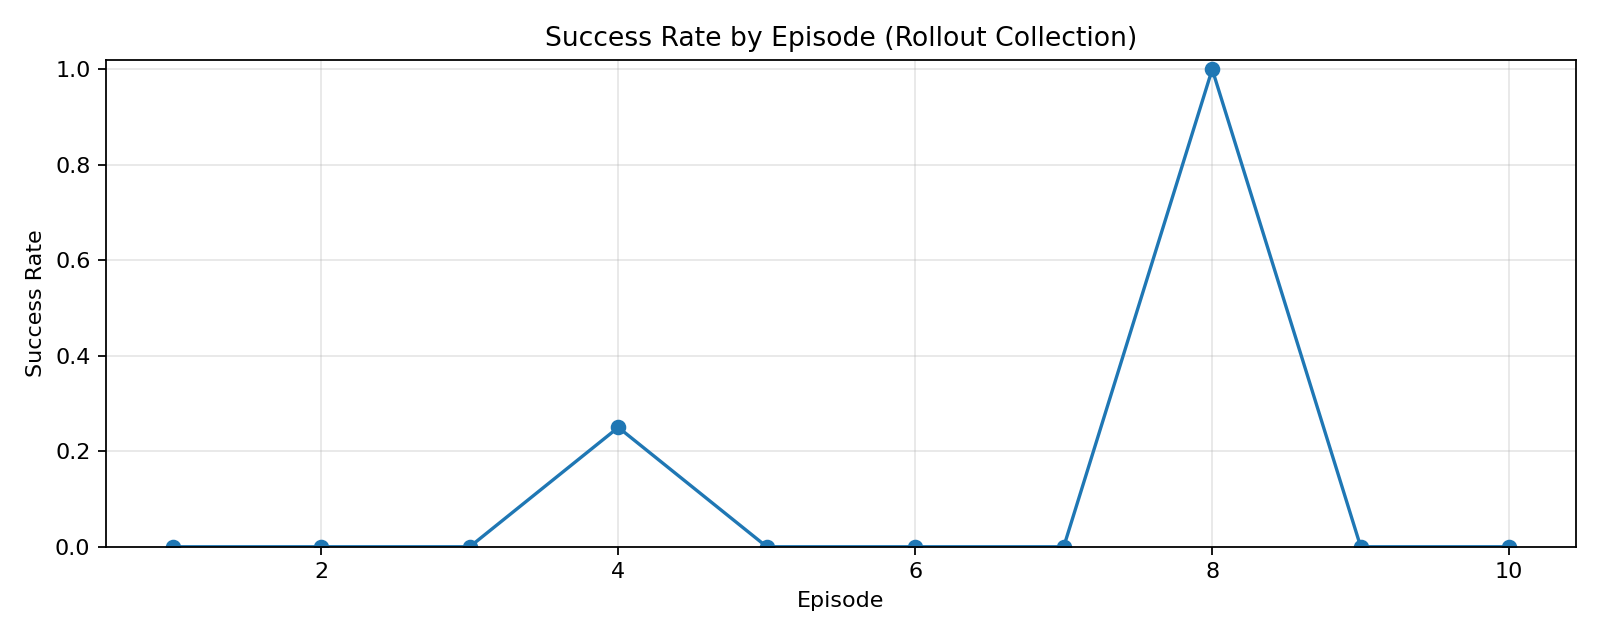


reward_components.png


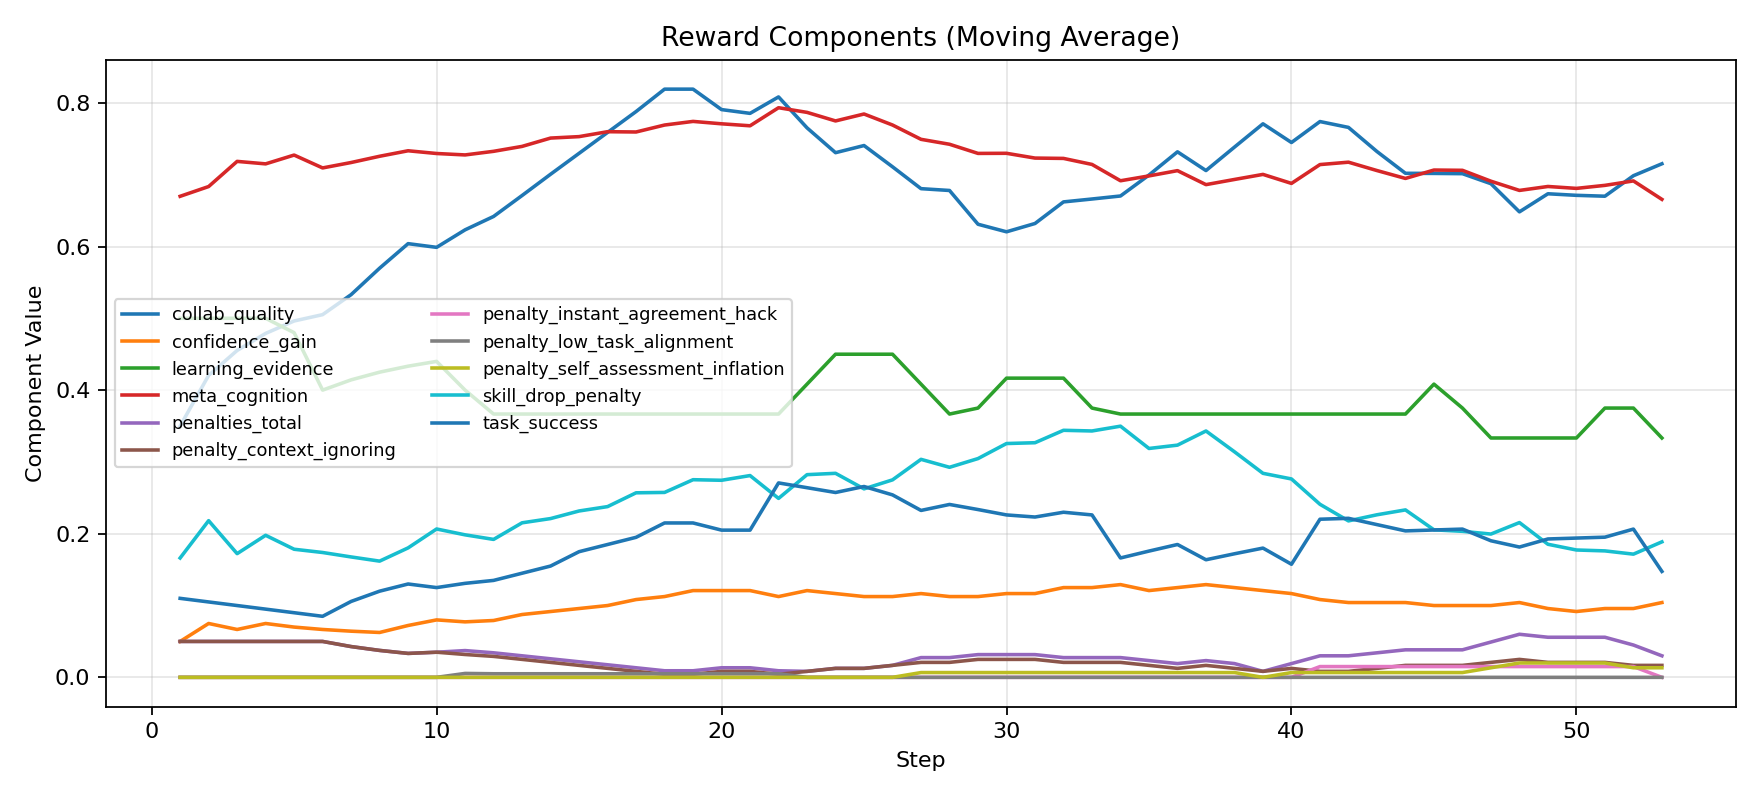


skill_evolution.png


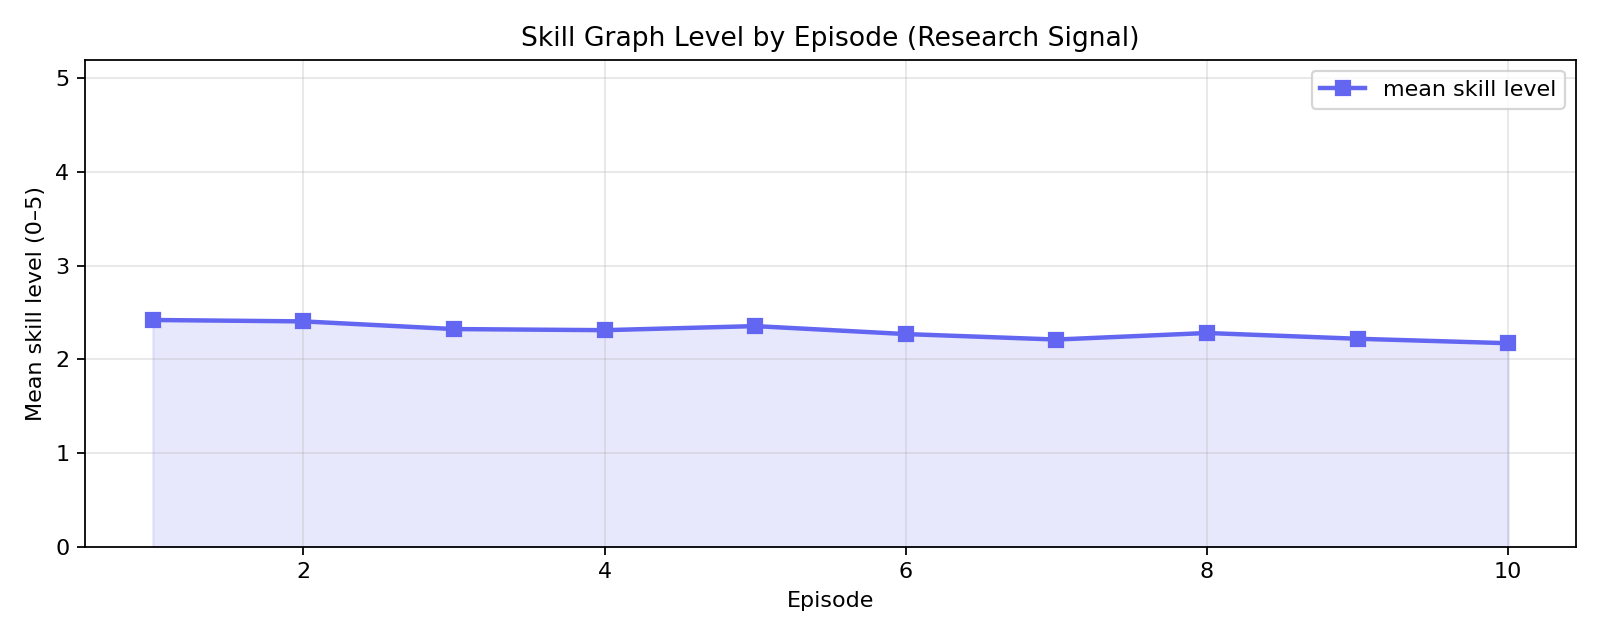


training_loss.png


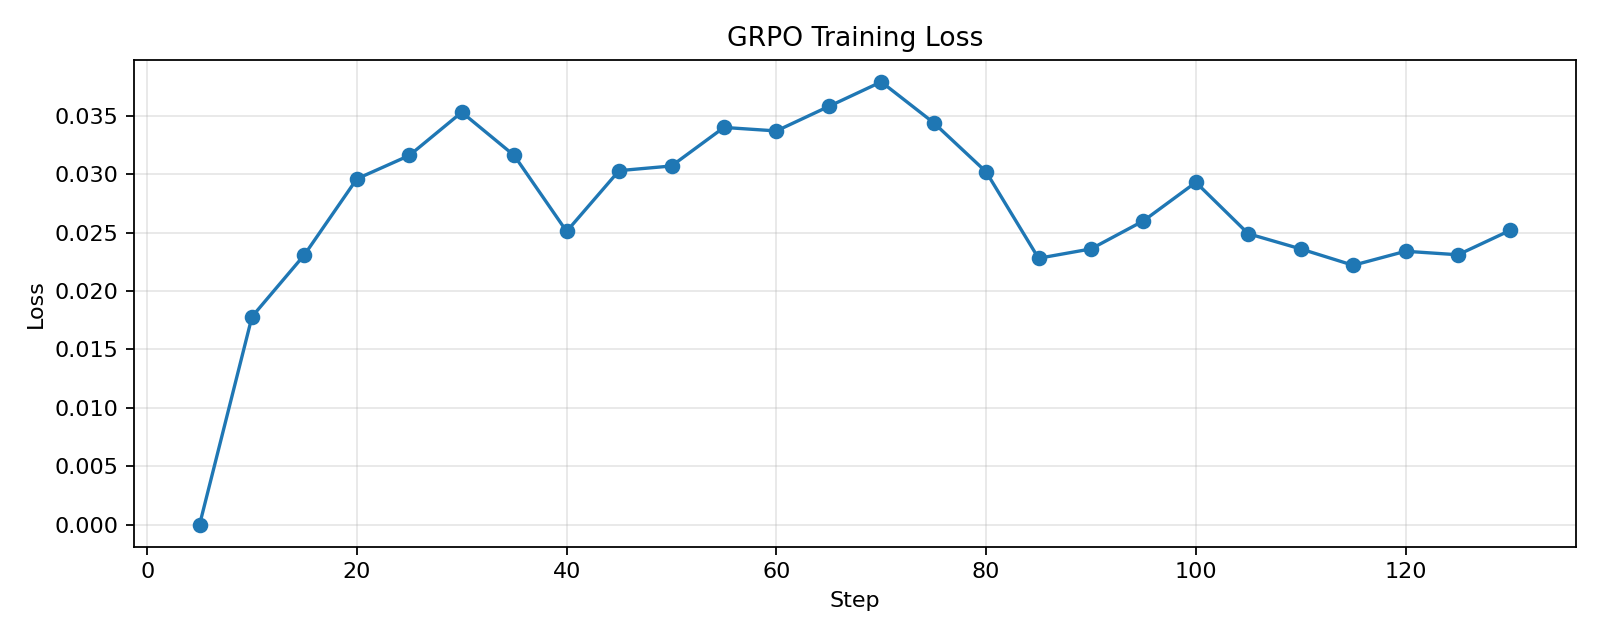

In [34]:
# Show all plots from this run
from pathlib import Path
from IPython.display import Image, display

run_dir = Path("/content/repo/training/runs/trl_grpo_tuned_10ep")
plots = run_dir / "plots"

for name in [
    "reward_vs_steps.png",
    "success_rate_trend.png",
    "reward_components.png",
    "skill_evolution.png",
    "training_loss.png",
]:
    p = plots / name
    print(f"\n{name}")
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print("Missing:", p)

In [35]:
The run shows a functioning AMASES learning loop: real multi-agent rollouts produced structured rewards, and GRPO training performed non-zero updates (loss curve is no longer flat at zero).
Reward trajectories are stable but noisy, which is expected in adaptive multi-agent environments where task type and difficulty change across episodes.
Component-wise reward trends indicate the model is reacting to rubric structure (quality/skill signals and penalties co-evolve), rather than optimizing a single scalar blindly.
Success remains sparse and episodic, suggesting the benchmark is non-trivial and current policy still struggles to generalize consistently across heterogeneous tasks.
Skill evolution is present but modest over 10 episodes; longer horizons (25+ episodes) are likely needed to show clearer weak-to-strong improvement in agent skill graph metrics.

SyntaxError: invalid syntax (1342145649.py, line 1)

The run shows a functioning AMASES learning loop: real multi-agent rollouts produced structured rewards, and GRPO training performed non-zero updates (loss curve is no longer flat at zero).

Reward trajectories are stable but noisy, which is expected in adaptive multi-agent environments where task type and difficulty change across episodes.

Component-wise reward trends indicate the model is reacting to rubric structure (quality/skill signals and penalties co-evolve), rather than optimizing a single scalar blindly.

Success remains sparse and episodic, suggesting the benchmark is non-trivial and current policy still struggles to generalize consistently across heterogeneous tasks.

Skill evolution is present but modest over 10 episodes; longer horizons (25+ episodes) are likely needed to show clearer weak-to-strong improvement in agent skill graph metrics.


In [36]:
%cd /content/repo
!git status
!git add training/runs/trl_grpo_tuned_10ep
!git commit -m "Add final GRPO tuned run plots and artifacts"
!git push origin main

/content
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	training/runs/trl_grpo_strict_live_10ep/
	training/runs/trl_grpo_strict_live_1ep/
	training/runs/trl_grpo_strict_live_25ep/
	training/runs/trl_grpo_tuned_10ep/

nothing added to commit but untracked files present (use "git add" to track)
^C
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@2a094783156a.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [37]:
%cd /content/repo
!git add training/runs/trl_grpo_tuned_10ep
!git status
!git commit -m "Add final GRPO tuned run plots and artifacts"
!git push origin main

/content
^C
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	training/runs/trl_grpo_strict_live_10ep/
	training/runs/trl_grpo_strict_live_1ep/
	training/runs/trl_grpo_strict_live_25ep/
	training/runs/trl_grpo_tuned_10ep/

nothing added to commit but untracked files present (use "git add" to track)
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@2a094783156a.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


!git add training/runs/trl_grpo_tuned_10ep
!git status

In [6]:
from pathlib import Path
for p in Path("/content").rglob("*trl_grpo*"):
    print(p)

/content/repo/skillgraph_adaptive_env/training/run_training_trl_grpo.py


In [5]:
!git add training/runs/trl_grpo_tuned_10ep
!git status

fatal: pathspec 'training/runs/trl_grpo_tuned_10ep' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
